# 05 — Modern Image Generators: StyleGAN, DALL-E, Stable Diffusion

## 📚 Learning Objectives

By completing this notebook, you will:
- **Describe how each of the three landmark systems works** — StyleGAN (GAN family), DALL-E (autoregressive/diffusion family), Stable Diffusion (latent diffusion) — and connect each to the architecture you already built in this course
- **Compare** the three across control, quality, openness, and hardware needs
- Re-run the **foundational GAN** all of them trace back to, as a hands-on anchor

*Honest scope note:* running the real systems requires GPUs and multi-GB model downloads, so this classroom notebook does not execute them. What runs here is the GAN foundation; the survey connects it to the production systems, and the references + Colab guide show the way to try the real ones.

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1 (GAN, StyleGAN) and Unit 3, lessons 01-04 (VAE, diffusion) — the production systems surveyed here are assembled from exactly those parts.

**Used later in:** Course 10 — Unit 4, which asks what these systems make possible and what that costs.

---

This notebook covers practical activities from **Course 10, Unit 3**:
- Understanding how AI images are generated by StyleGAN, DALL-E, and Stable Diffusion

---

## 🌍 Why this lesson exists — openness cuts both ways

In February 2023 Getty Images sued Stability AI in the United States, and separately in the UK High Court, alleging that Stability copied millions of Getty photographs to train Stable Diffusion. Part of Getty's evidence was straightforward: the **Getty watermark appearing in generated outputs**.

Hold both halves of that at once. Open weights are the reason you can run Stable Diffusion in a classroom, fine-tune it with LoRA, and control it with ControlNet — none of which is possible with DALL·E. Open *training-data practice* is what put it in court. The "openness" row of the comparison table below is not a footnote; it is usually the row that decides the project.

**What goes wrong without this:** a student who can name the mechanism but not the access model, licence and provenance cannot make a build-or-buy recommendation. In a procurement meeting, "it uses cross-attention on CLIP embeddings" answers no question anyone asked.


## The Three Systems, Mapped to What You Built

**StyleGAN (NVIDIA, 2019–)** — the GAN family's peak. Your unit-1 GAN (example 05) + the mapping network / style injection / truncation ideas from unit-1 example 07, scaled to 1024×1024 faces. Strengths: unmatched sharpness on narrow domains (faces), fine-grained *style* control. Weaknesses: per-domain training, no text control.

**DALL-E (OpenAI, 2021–)** — text-to-image. DALL-E 1 generated image *tokens* autoregressively (the unit-2 mechanism, pointed at pixels); DALL-E 2/3 switched to **diffusion** guided by text embeddings — the exact mechanism of example 04 plus text conditioning. Strengths: open-ended prompts. Weaknesses: closed model, API-only.

**Stable Diffusion (Stability AI/LMU, 2022–)** — open-source **latent diffusion**: example 04's DDPM run inside example 01's VAE latent space, steered by CLIP text embeddings through cross-attention. Strengths: open weights, runs on consumer GPUs, huge ecosystem (LoRA fine-tunes, ControlNet). Weaknesses: quality depends on prompt/negative-prompt craft.


In [1]:
# WHAT/WHY: put the three systems side by side in one printed comparison
# table — the survey's reference summary (from the cited papers/docs).
import pandas as pd

comparison = pd.DataFrame({
    "StyleGAN":         ["GAN (adversarial)", "none (unconditional/domain)", "narrow domain, ultra-sharp",
                         "open weights", "GPU for training, modest for sampling", "unit 1, examples 05+07"],
    "DALL-E 2/3":       ["diffusion + text", "text prompt", "open-ended scenes",
                         "closed (API only)", "cloud only", "example 04 + text conditioning"],
    "Stable Diffusion": ["latent diffusion + text", "text prompt (+ControlNet etc.)", "open-ended scenes",
                         "open weights", "consumer GPU (~8 GB)", "examples 01 (VAE) + 04 (DDPM)"],
}, index=["core mechanism", "control signal", "output domain",
          "openness", "hardware", "you built the core in"])

with pd.option_context("display.max_colwidth", 40, "display.width", 150):
    print(comparison.to_string())


                                                    StyleGAN                      DALL-E 2/3                Stable Diffusion
core mechanism                             GAN (adversarial)                diffusion + text         latent diffusion + text
control signal                   none (unconditional/domain)                     text prompt  text prompt (+ControlNet etc.)
output domain                     narrow domain, ultra-sharp               open-ended scenes               open-ended scenes
openness                                        open weights               closed (API only)                    open weights
hardware               GPU for training, modest for sampling                      cloud only            consumer GPU (~8 GB)
you built the core in                 unit 1, examples 05+07  example 04 + text conditioning   examples 01 (VAE) + 04 (DDPM)


## 💬 Discuss

1. The "openness" row reads: open weights, closed API, open weights. For a Saudi government client with data-residency requirements, which row of this table decides the choice — and does the "core mechanism" row matter to that decision at all?
2. Our anchor GAN trains in minutes; StyleGAN needs GPU-days and Stable Diffusion needed a datacentre. What can you honestly claim to have learned about the large systems from the small one? Write the sentence you would defend, and the sentence you would not.
3. Getty's evidence included its own watermark appearing in generated images. What does that do to the argument that "the model only learns statistics, it does not store images"? (Compare Carlini et al., 2023, arXiv 2301.13188.)


## 🌍 Hands-On Anchor — the GAN They All Trace Back To

Everything above descends from the 2014 adversarial idea. As the runnable anchor for this survey, here is the small **fully-connected GAN** from unit 1 (a real DCGAN adds convolutions), generating digits from noise.


Epoch 2/8 — D loss: 0.453  G loss: 2.362


Epoch 4/8 — D loss: 0.538  G loss: 1.747


Epoch 6/8 — D loss: 0.436  G loss: 2.715


Epoch 8/8 — D loss: 0.477  G loss: 2.255


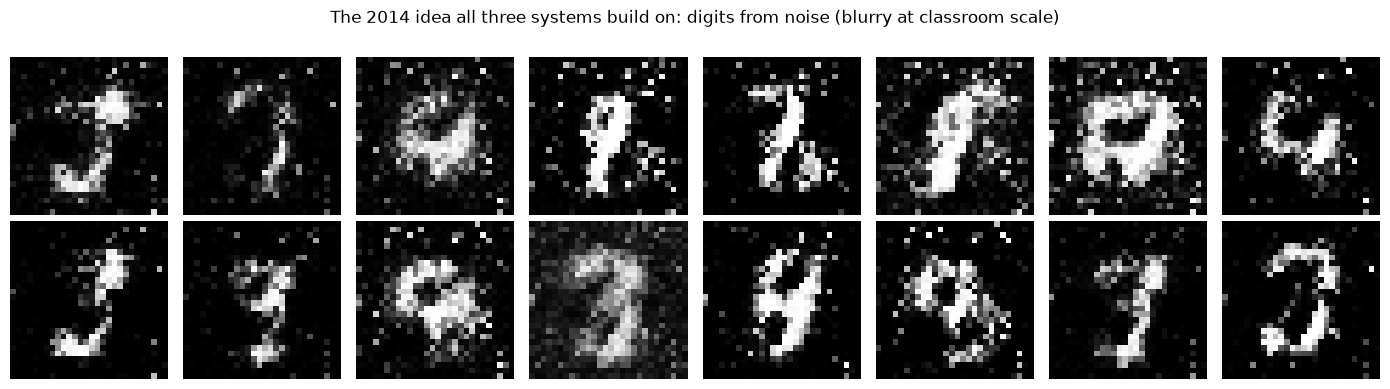

In [2]:
# WHAT/WHY: re-run the foundational GAN (unit 1, example 05) as this survey's
# hands-on anchor — adversarial training, then digits sampled from pure noise.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
subset    = torch.utils.data.Subset(dataset, range(25_600))
loader    = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# Generator: noise → image; Discriminator: image → real/fake probability
G = nn.Sequential(nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
                  nn.Linear(256, 512), nn.LeakyReLU(0.2),
                  nn.Linear(512, 28*28), nn.Tanh())
D = nn.Sequential(nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(256, 1), nn.Sigmoid())
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

EPOCHS = 8
for epoch in range(EPOCHS):
    for real_imgs, _ in loader:
        bs = real_imgs.size(0); real_flat = real_imgs.view(bs, -1)
        # D step: real → 1, detached fakes → 0
        fake = G(torch.randn(bs, LATENT_DIM)).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # G step: fool D
        fake = G(torch.randn(bs, LATENT_DIM))
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Sample digits from pure noise, shown inline ───────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray', vmin=-1, vmax=1); ax.axis('off')
plt.suptitle("The 2014 idea all three systems build on: digits from noise (blurry at classroom scale)")
plt.tight_layout(); plt.show()


## Trying the Real Systems

- **Stable Diffusion**: free on Colab with `diffusers` — see `../../DOCS/COLAB_SETUP.md`; a GPU runtime generates a 512×512 image from your prompt in seconds
- **StyleGAN**: pretrained checkpoints at the official [StyleGAN3 repo](https://github.com/NVlabs/stylegan3); [thispersondoesnotexist.com](https://thispersondoesnotexist.com) shows live output
- **DALL-E**: via the OpenAI API / ChatGPT (paid)


## ⚠️ Where this breaks

**Nothing here runs the three systems**, so nothing here is evidence about their quality. Treat every quality claim in the table as literature you have read, not as a measurement you have made — and say so when you present it.

**The table is a snapshot with a short half-life.** The GAN row has been production-marginal since 2022; the current lineage is latent diffusion with transformer backbones (Peebles & Xie, 2022, arXiv 2212.09748) and flow matching (Lipman et al., 2022, arXiv 2210.02747), and by 2026 understanding and generation are converging into single unified models. Re-derive the table before you brief a client from it.

**"Open weights" is not "open data" and not "unrestricted use".** These are three separate things and they fail separately: the licence governs what you may do with the model, the provenance governs what the model may have absorbed, and Getty v. Stability is about the second. Check both, in writing, before recommending a checkpoint for commercial work.

**The hands-on anchor is an anchor, not a proxy.** It shows you the adversarial mechanism. It tells you nothing about the data curation, distributed training, safety filtering and inference economics that make up most of the engineering in a production generator.


## 📚 References & Further Reading

**Papers:**
- Karras et al. (2019) — [StyleGAN](https://arxiv.org/abs/1812.04948)
- Ramesh et al. (2022) — [DALL-E 2: Hierarchical Text-Conditional Image Generation](https://arxiv.org/abs/2204.06125)
- Rombach et al. (2022) — [Stable Diffusion: Latent Diffusion Models](https://arxiv.org/abs/2112.10752)
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(where it all started)*


## 📝 Summary

In **05 — Modern Image Generators** you mapped the three landmark systems onto the architectures you built in this course: StyleGAN = your GAN + style machinery; DALL-E = autoregressive/diffusion generation + text; Stable Diffusion = your example-04 DDPM inside your example-01 VAE latent space + CLIP text conditioning. The comparison table summarizes their trade-offs, and the hands-on anchor re-ran the foundational GAN. Running the production systems needs GPU hardware — the "Trying the Real Systems" section shows the routes.
